TRABAJO FINAL - TELECOMUNICACIONES
OBJETIVO:  Analizar los datos de la Compañia "A" y construir un modelo de aprendizaje automático cuyo resultado respalde una propuesta de negocio concreta, no en construir el mejor modelo posible.

# 1 CONFIGURACION Y CARGA DE DATOS

Importacion de Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)

Conectarse con Google Drive

In [ ]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Una vez conectado con google drive, accerdo a la fuente de datos que he cargado previamente en el drive

In [ ]:
#%cd "/content/drive/MyDrive/GCI 2026/Final Assignment"
%cd "/content/drive/MyDrive/GCI 2026/Final Assignment"

/content/drive/MyDrive/GCI 2026/Final Assignment


Cargar las dos tablas de origen: "Client" y "Record"

In [ ]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/GCI 2026/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/GCI 2026/Final Assignment/telecom/Record.csv


In [ ]:
#Defimnimos los dataframes como "client" y "record" y revisamos la longitud de filas y columnas
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


Unimos las dos tablas "Client" y "Record" en un solo Dataframe que los lllamaremos df

In [ ]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


# 2. ANALISIS EXPLORATORIO DE DATOS (EDA)
Responderemos las siguientes preguntas:
1. ¿Qué tamaño y estructura tienen los datos? Filas, columnas, tipos de datos.
2. ¿En qué puntos los datos son incompletos o poco fiables?
3. ¿Qué aspecto tiene la variable objetivo?

In [ ]:
# ¿Que tamaño tienen los datos?
print(df.shape)

(100000, 100)


El tamaño de nuestra data es de 100000 filas con 100 columnas, es decir tenemos 100 variables, nos queda analizar que informacion tiene cada una de estas

In [ ]:
# ¿Que tipos de Datos son?
tipos = df.dtypes.to_dict()
for columna, tipo in tipos.items():
    print(f"{columna}: {tipo}")

rev_Mean: float64
mou_Mean: float64
totmrc_Mean: float64
da_Mean: float64
ovrmou_Mean: float64
ovrrev_Mean: float64
vceovr_Mean: float64
datovr_Mean: float64
roam_Mean: float64
change_mou: float64
change_rev: float64
drop_vce_Mean: float64
drop_dat_Mean: float64
blck_vce_Mean: float64
blck_dat_Mean: float64
unan_vce_Mean: float64
unan_dat_Mean: float64
plcd_vce_Mean: float64
plcd_dat_Mean: float64
recv_vce_Mean: float64
recv_sms_Mean: float64
comp_vce_Mean: float64
comp_dat_Mean: float64
custcare_Mean: float64
ccrndmou_Mean: float64
cc_mou_Mean: float64
inonemin_Mean: float64
threeway_Mean: float64
mou_cvce_Mean: float64
mou_cdat_Mean: float64
mou_rvce_Mean: float64
owylis_vce_Mean: float64
mouowylisv_Mean: float64
iwylis_vce_Mean: float64
mouiwylisv_Mean: float64
peak_vce_Mean: float64
peak_dat_Mean: float64
mou_peav_Mean: float64
mou_pead_Mean: float64
opk_vce_Mean: float64
opk_dat_Mean: float64
mou_opkv_Mean: float64
mou_opkd_Mean: float64
drop_blk_Mean: float64
attempt_Mean: float6

In [ ]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


In [ ]:
conteo_tipos = df.dtypes.value_counts()
print(conteo_tipos)

float64    69
object     21
int64      10
Name: count, dtype: int64


Como la mayoria de los modelos de aprendizaje automatico solo aprenden de números, por lo que las columnas de texto deberán convertirse a formato numérico antes de su modelado, en este caso nos preocuparemos en definir la variable objetivo, con las variables explicativas, para que el trabajo de modelado sea mas limpio, y trabajar con la data especificamente necesaria

Tenemos 69 columnas con numeros decimales, 21 columnas con cadenas de texto y 10 con numeros enteros

In [ ]:
#¿Datos incompletos o poco fiables?
Datosfalt = df.isnull().sum().to_dict()

for columna, faltantes in Datosfalt.items():
    print(f"{columna}: {faltantes}")

rev_Mean: 357
mou_Mean: 357
totmrc_Mean: 357
da_Mean: 357
ovrmou_Mean: 357
ovrrev_Mean: 357
vceovr_Mean: 357
datovr_Mean: 357
roam_Mean: 357
change_mou: 891
change_rev: 891
drop_vce_Mean: 0
drop_dat_Mean: 0
blck_vce_Mean: 0
blck_dat_Mean: 0
unan_vce_Mean: 0
unan_dat_Mean: 0
plcd_vce_Mean: 0
plcd_dat_Mean: 0
recv_vce_Mean: 0
recv_sms_Mean: 0
comp_vce_Mean: 0
comp_dat_Mean: 0
custcare_Mean: 0
ccrndmou_Mean: 0
cc_mou_Mean: 0
inonemin_Mean: 0
threeway_Mean: 0
mou_cvce_Mean: 0
mou_cdat_Mean: 0
mou_rvce_Mean: 0
owylis_vce_Mean: 0
mouowylisv_Mean: 0
iwylis_vce_Mean: 0
mouiwylisv_Mean: 0
peak_vce_Mean: 0
peak_dat_Mean: 0
mou_peav_Mean: 0
mou_pead_Mean: 0
opk_vce_Mean: 0
opk_dat_Mean: 0
mou_opkv_Mean: 0
mou_opkd_Mean: 0
drop_blk_Mean: 0
attempt_Mean: 0
complete_Mean: 0
callfwdv_Mean: 0
callwait_Mean: 0
churn: 0
months: 0
Customer_ID: 0
uniqsubs: 0
actvsubs: 0
new_cell: 0
crclscod: 0
asl_flag: 0
totcalls: 0
totmou: 0
totrev: 0
adjrev: 0
adjmou: 0
adjqty: 0
avgrev: 0
avgmou: 0
avgqty: 0
avg3mou: 

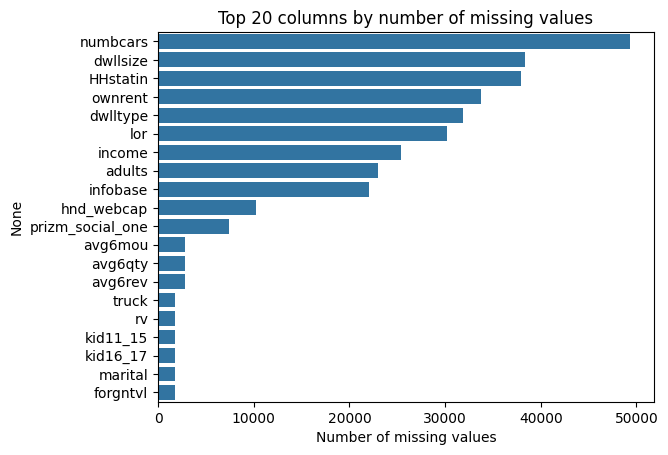

In [ ]:
# Conteo de columnas de valores faltantes
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

Se evidencia que variables como: prizm_social_one: 7388, hnd_webcap: 10189 ownrent: 33706, lor: 30190, dwlltype: 31909, adults: 23019, infobase: 22079,income: 25436, numbcars: 49366, HHstatin: 37923, dwllsize: 38308, tiene valores faltantes con gran significancia, por lo que imputarlos, con la media, mediana, moda, podria causar sesgo al modelo, analizaremos la relevancia de cada variable ante una posible eliminacion mas adelante.

¿Qué aspecto tiene la variable objetivo?
Para responder esta pregunta, primero vamos a determinar la hipotesis que queremos estudiar, a partir de esto plantearemos la propuesta comercial para la compañia "A"

En la investigacion de mercado dentro del mercado de Telecomunicaciones inalambrica de mi pais, existen 3 operadores que se hacen con mas del 80% de la cuota de Mercado, estas son: CONECEL (53.3%), OTECEL(28.8%) y CNT (17.9%) AL 2024 (FUENTE: https://www.arcotel.gob.ec/wp-content/uploads/2015/01/Boletin-cierre-2024_compressed-1.pdf).

La pregunta con la empezamos el analisis se basara en que la Compañia "A" tiene la mayor parte de cuota del mercado, por lo tanto busca fidelizacion de sus clientes, en este caso se pregunta ¿Como lograr la fidelizacion de los clientes, sin que resulte atractivo para el cliente la portabilidad que pudiese ofrecer la competencia?

Lo que supondra en el presente analisis, es que la empresa "A" corresponde a CONECEL, que busca fidelizacion de los clientes, ante eventuales salidas de los clientes por promociones de portabilidad de la competencia. En este caso la propuesta se basara en predecir los posibles clientes que excedan el consumo limite de su plan, y actuar anticipadamente para ofrecerles un incremento en la bondades de su plan para evitar cargos exesivos, es decir, la empresa buscara transformar ingresos "ocasionales" por consumos ocacionales, en ingresos recurrentes y predecibles mediante planes personalizados

Una vez que hemos identificado la necesidad de la compañia "A" y establecido la propuesta comercial, a continuacion definimos nuestra variable objetivo, en este caso seria: ovrrev_Mean (Ingresos por exceso de consumo promedio), esta variable nos entrega el monto en $ promedio de consumo por exceso en los planes. Ahora identificaremos las variable que podrian explicar a nuestra variable objetivo las cuales se determinan segun el siguiente criterio:

**Variables de uso y consumo:**
mou_Mean → minutos promedio de uso mensual.
totmrc_Mean → cargo mensual recurrente.
ovrmou_Mean → minutos de exceso de consumo.
datovr_Mean → ingresos por exceso de datos.
vceovr_Mean → ingresos por exceso de voz.

*Justificación:* el exceso de consumo está directamente relacionado con el nivel de uso y los cargos recurrentes.

**Variables de comportamiento dinámico**
change_mou → variación en minutos de uso.
change_rev → variación en ingresos mensuales.

*Justificación:* cambios bruscos en uso o gasto anticipan exceso de consumo.

**Variables de calidad de red**
drop_vce_Mean → llamadas de voz interrumpidas.
drop_dat_Mean → llamadas de datos interrumpidas.
blck_vce_Mean → llamadas bloqueadas de voz.
blck_dat_Mean → llamadas bloqueadas de datos.

*Justificación:* clientes con mala calidad de red pueden tener patrones de consumo irregulares que generan cargos extra.

**Variables de interacción con soporte**
custcare_Mean → llamadas a atención al cliente.
cc_mou_Mean → minutos de uso en atención al cliente.

*Justificación:* alto contacto con soporte puede indicar problemas de facturación o consumo excesivo.

**Variables de perfil del cliente**
months → antigüedad del cliente.
income → ingresos estimados.
hnd_price → precio del equipo.
area → zona geográfica.

*Justificación:* el perfil socioeconómico y la antigüedad influyen en la probabilidad de exceder consumo.

Constuimos el nuevo Dataframe con las variables seleccionadas


# 3. PREPROCESAMIENTO

In [ ]:
# Lista de variables seleccionadas
variables_modelo = [ "ovrrev_Mean", "mou_Mean", "totmrc_Mean", "ovrmou_Mean", "vceovr_Mean", "datovr_Mean", "roam_Mean", "change_mou", "change_rev", "drop_vce_Mean", "drop_dat_Mean",
                    "blck_vce_Mean", "blck_dat_Mean", "custcare_Mean", "cc_mou_Mean", "months", "income", "hnd_price", "area", "Customer_ID"
]

# Crear DataFrame con solo esas columnas
df_modelo = df[variables_modelo]

# Verificar
df_modelo.head()

,ovrrev_Mean,mou_Mean,totmrc_Mean,ovrmou_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,custcare_Mean,cc_mou_Mean,months,income,hnd_price,area,Customer_ID
0,0.0,219.25,22.500,0.00,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,0.000000,0.000000,61,4.0,149.98999,NORTHWEST/ROCKY MOUNTAIN AREA,1000001
1,9.1,482.75,37.425,22.75,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,1.666667,5.463333,56,5.0,NaN,CHICAGO AREA,1000002
2,0.0,10.25,16.990,0.00,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,0.000000,0.000000,58,5.0,29.98999,GREAT LAKES AREA,1000003
3,0.0,7.50,38.000,0.00,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,60,6.0,29.98999,CHICAGO AREA,1000004
4,0.0,570.50,71.980,0.00,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,8.666667,11.076667,57,6.0,149.98999,NEW ENGLAND AREA,1000005


In [ ]:
#Verificamos los valores nulos del dataframe
df_modelo.isnull().sum()

,0
ovrrev_Mean,357
mou_Mean,357
totmrc_Mean,357
ovrmou_Mean,357
vceovr_Mean,357
datovr_Mean,357
roam_Mean,357
change_mou,891
change_rev,891
drop_vce_Mean,0


In [ ]:
#Elimino la variable income, ya que corresponde a mas del 20% del dataframe, si llego a imputar podria sesgar al modelo
df_modelo = df_modelo.drop('income', axis=1)

Antes de imputar los valores faltantes procedo a generar una columna binaria para que me diga, si ha existido valor faltante

In [ ]:
# Crear columnas indicadoras de missing para las variables con valores faltantes
cols_con_missing = [ "ovrrev_Mean", "mou_Mean", "totmrc_Mean",  "ovrmou_Mean",
    "vceovr_Mean", "datovr_Mean", "roam_Mean", "change_mou", "change_rev",
    "hnd_price", "area"
]

# Generar columnas binarias (1 = faltante, 0 = no faltante)
for col in cols_con_missing:
    df_modelo[col + "_missing"] = df_modelo[col].isnull().astype(int)

# Verificar
df_modelo.head()


/tmp/ipykernel_634/968614446.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo[col + "_missing"] = df_modelo[col].isnull().astype(int)
/tmp/ipykernel_634/968614446.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo[col + "_missing"] = df_modelo[col].isnull().astype(int)
/tmp/ipykernel_634/968614446.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

,ovrrev_Mean,mou_Mean,totmrc_Mean,ovrmou_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,custcare_Mean,cc_mou_Mean,months,income,hnd_price,area,Customer_ID,ovrrev_Mean_missing,mou_Mean_missing,totmrc_Mean_missing,ovrmou_Mean_missing,vceovr_Mean_missing,datovr_Mean_missing,roam_Mean_missing,change_mou_missing,change_rev_missing,hnd_price_missing,area_missing
0,0.0,219.25,22.500,0.00,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,0.000000,0.000000,61,4.0,149.98999,NORTHWEST/ROCKY MOUNTAIN AREA,1000001,0,0,0,0,0,0,0,0,0,0,0
1,9.1,482.75,37.425,22.75,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,1.666667,5.463333,56,5.0,NaN,CHICAGO AREA,1000002,0,0,0,0,0,0,0,0,0,1,0
2,0.0,10.25,16.990,0.00,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,0.000000,0.000000,58,5.0,29.98999,GREAT LAKES AREA,1000003,0,0,0,0,0,0,0,0,0,0,0
3,0.0,7.50,38.000,0.00,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,60,6.0,29.98999,CHICAGO AREA,1000004,0,0,0,0,0,0,0,0,0,0,0
4,0.0,570.50,71.980,0.00,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,8.666667,11.076667,57,6.0,149.98999,NEW ENGLAND AREA,1000005,0,0,0,0,0,0,0,0,0,0,0


Ahora procedo a imputar los datos de la columnas con valores faltantes: ovrrev_Mean, mou_Mean, totmrc_Mean, ovrmou_Mean, vceovr_Mean, datovr_Mean, roam_Mean, change_mou, change_rev, hnd_price. Imputo con la mediana general por tener pocos valores faltantes dentro de las columnas



No se realiza con la variable "area" ya que es una variable categorica

In [ ]:
# Lista de columnas a imputar con la mediana
cols_imputar = [
    "ovrrev_Mean",
    "mou_Mean",
    "totmrc_Mean",
    "ovrmou_Mean",
    "vceovr_Mean",
    "datovr_Mean",
    "roam_Mean",
    "change_mou",
    "change_rev",
    "hnd_price"
]

# Imputación con la mediana
for col in cols_imputar:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

/tmp/ipykernel_634/377890290.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())


In [ ]:
df_modelo.head()

,ovrrev_Mean,mou_Mean,totmrc_Mean,ovrmou_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,custcare_Mean,cc_mou_Mean,months,income,hnd_price,area,Customer_ID,ovrrev_Mean_missing,mou_Mean_missing,totmrc_Mean_missing,ovrmou_Mean_missing,vceovr_Mean_missing,datovr_Mean_missing,roam_Mean_missing,change_mou_missing,change_rev_missing,hnd_price_missing,area_missing
0,0.0,219.25,22.500,0.00,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,0.000000,0.000000,61,4.0,149.98999,NORTHWEST/ROCKY MOUNTAIN AREA,1000001,0,0,0,0,0,0,0,0,0,0,0
1,9.1,482.75,37.425,22.75,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,1.666667,5.463333,56,5.0,99.98999,CHICAGO AREA,1000002,0,0,0,0,0,0,0,0,0,1,0
2,0.0,10.25,16.990,0.00,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,0.000000,0.000000,58,5.0,29.98999,GREAT LAKES AREA,1000003,0,0,0,0,0,0,0,0,0,0,0
3,0.0,7.50,38.000,0.00,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,60,6.0,29.98999,CHICAGO AREA,1000004,0,0,0,0,0,0,0,0,0,0,0
4,0.0,570.50,71.980,0.00,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,8.666667,11.076667,57,6.0,149.98999,NEW ENGLAND AREA,1000005,0,0,0,0,0,0,0,0,0,0,0


Para conocer cual es el ingreso promedio por consumo en exceso, voy a realizar un grafico de pastel por area

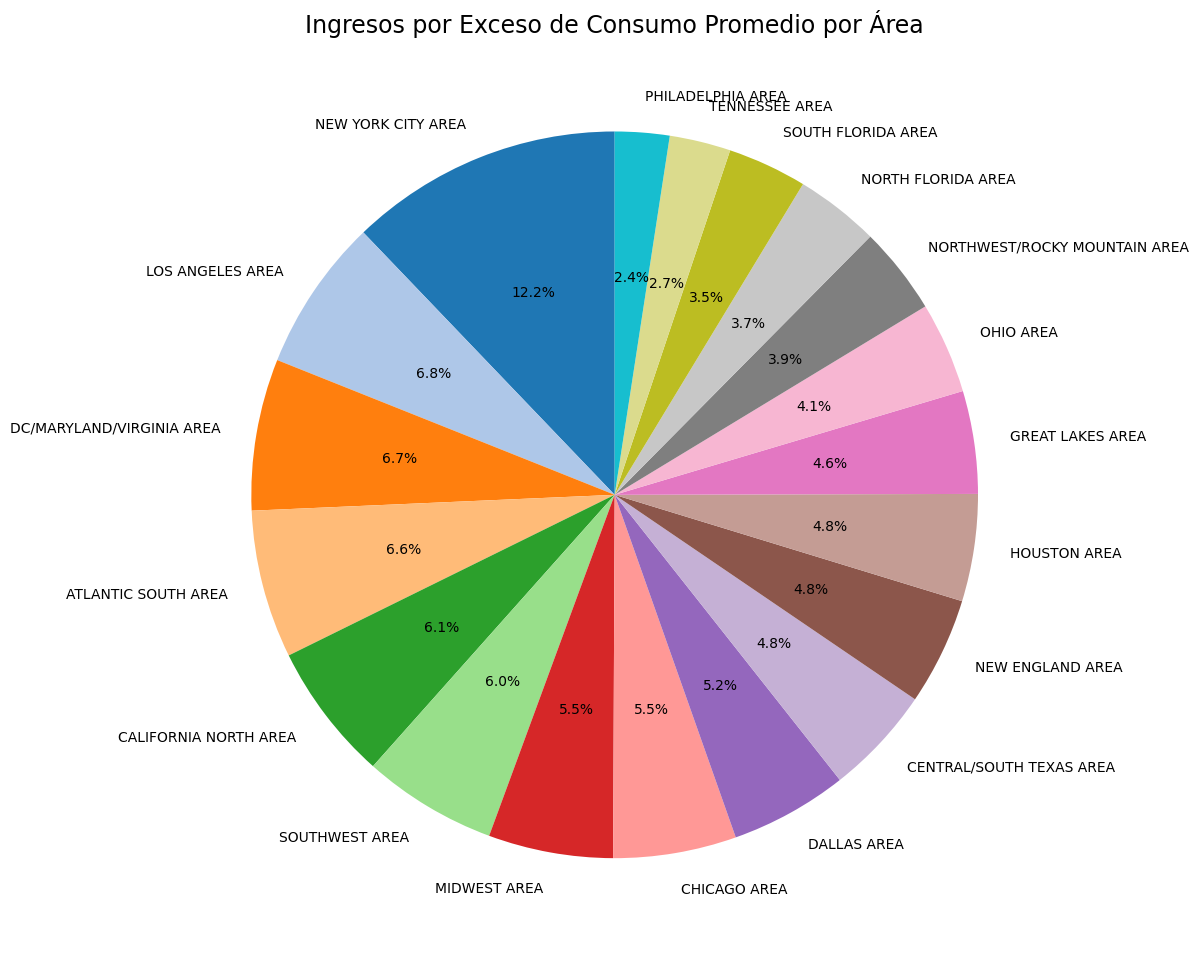

In [ ]:
# Crear gráfico circular
 #Calcular el promedio de ovrrev_Mean por área
df_area = df_modelo.groupby('area')['ovrrev_Mean'].sum().reset_index()

# Ordenar por valor descendente (opcional)
df_area = df_area.sort_values(by='ovrrev_Mean', ascending=False)
plt.figure(figsize=(12,12))
plt.pie(
    df_area['ovrrev_Mean'],
    labels=df_area['area'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.tab20.colors
)
plt.title('Ingresos por Exceso de Consumo Promedio por Área', fontsize=17)
plt.tight_layout()
plt.show()

Ahora voy a graficar un grafico de barras, para conocer cuanto ingresa por area por exceso de consumo, en terminos monetarios

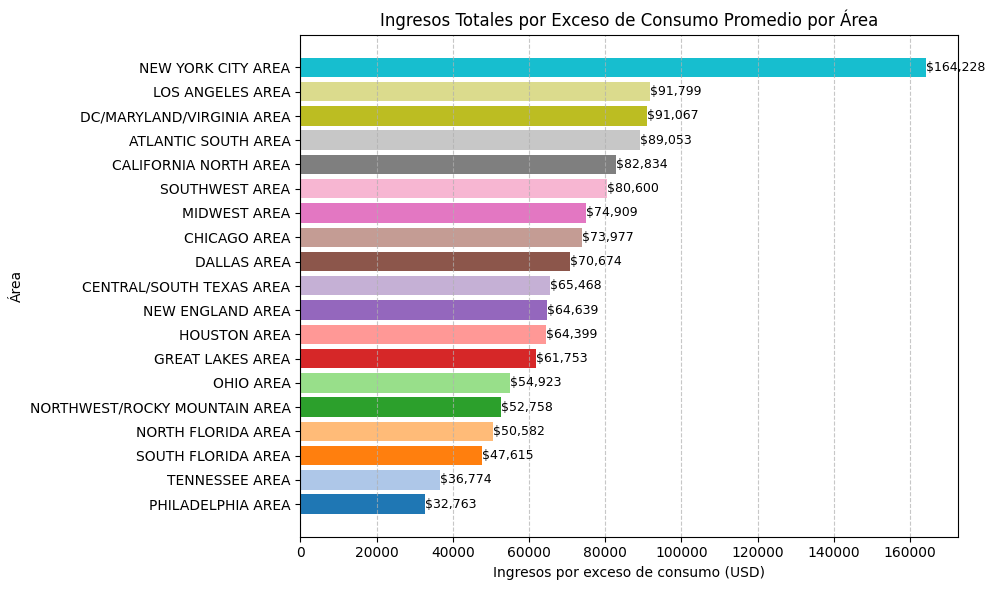

In [ ]:
# Sumar ingresos por área
ingresos_area = df_modelo.groupby('area')['ovrrev_Mean'].sum().reset_index()

# Ordenar de menor a mayor
ingresos_area = ingresos_area.sort_values(by='ovrrev_Mean', ascending=True)

# Gráfico de barras horizontales
palette = plt.cm.tab20(range(len(ingresos_area)))

plt.figure(figsize=(10,6))
bars = plt.barh(ingresos_area['area'], ingresos_area['ovrrev_Mean'], color=palette)

# Etiquetas con valores monetarios
for bar, valor in zip(bars, ingresos_area['ovrrev_Mean']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f"${valor:,.0f}", va='center', ha='left', fontsize=9)

plt.xlabel('Ingresos por exceso de consumo (USD)')
plt.ylabel('Área')
plt.title('Ingresos Totales por Exceso de Consumo Promedio por Área')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Sumar toda la columna ovrrev_Mean
total_ingresos = df_modelo['ovrrev_Mean'].sum()

print("Total de ingresos por exceso de consumo:", total_ingresos)

Total de ingresos por exceso de consumo: 1351472.232499927


El total de ingreso promedio que ha facturado la compañia "A" por consumo en exceso es de 1 351 472.2325 USD

Ahora bien, la variable categorica area verifico cuantos niveles tiene y procedó a imputar

In [ ]:
# Ver cuántos niveles únicos tiene 'area'
niveles_area = df_modelo['area'].nunique()
print("Número de niveles en area:", niveles_area)

# Ver cuáles son esos niveles
print(df_modelo['area'].unique())


Número de niveles en area: 19
['NORTHWEST/ROCKY MOUNTAIN AREA' 'CHICAGO AREA' 'GREAT LAKES AREA'
 'NEW ENGLAND AREA' 'DALLAS AREA' 'CENTRAL/SOUTH TEXAS AREA'
 'TENNESSEE AREA' 'MIDWEST AREA' 'PHILADELPHIA AREA' 'OHIO AREA'
 'HOUSTON AREA' 'SOUTHWEST AREA' 'NEW YORK CITY AREA'
 'ATLANTIC SOUTH AREA' 'SOUTH FLORIDA AREA' 'CALIFORNIA NORTH AREA'
 'DC/MARYLAND/VIRGINIA AREA' 'NORTH FLORIDA AREA' nan 'LOS ANGELES AREA']


Toda vez que conocemos que son 19 categorias vamos a proceder a establecer la codificacion one hoy a la variable "area"

In [ ]:
# Aplicar One-Hot Encoding a la variable 'area'
df_modelo = pd.get_dummies(df_modelo, columns=['area'], prefix='area').astype(int)
df_modelo.head()

,ovrrev_Mean,mou_Mean,totmrc_Mean,ovrmou_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,custcare_Mean,cc_mou_Mean,months,hnd_price,Customer_ID,ovrrev_Mean_missing,mou_Mean_missing,totmrc_Mean_missing,ovrmou_Mean_missing,vceovr_Mean_missing,datovr_Mean_missing,roam_Mean_missing,change_mou_missing,change_rev_missing,hnd_price_missing,area_missing,area_ATLANTIC SOUTH AREA,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_HOUSTON AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_PHILADELPHIA AREA,area_SOUTH FLORIDA AREA,area_SOUTHWEST AREA,area_TENNESSEE AREA
0,0,219,22,0,0,0,0,-157,-18,0,0,0,0,0,0,61,149,1000001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,9,482,37,22,9,0,0,532,50,8,0,1,0,1,5,56,99,1000002,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,10,16,0,0,0,0,-4,0,0,0,0,0,0,0,58,29,1000003,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,0,7,38,0,0,0,0,-1,0,0,0,0,0,0,0,60,29,1000004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,570,71,0,0,0,0,38,0,9,0,0,0,8,11,57,149,1000005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


Se ha procedido a imputar los valores faltantes con la mediana global de las variables numericas y se ha aplicado one hot a la variable categorica area. Ahora vamos a revisar cual es el comportamiento de la variable.

Ahora bien, vamos a revisar los valores correspondientes a $, cambiamos a float

In [ ]:
df_modelo['ovrrev_Mean'] = df_modelo['ovrrev_Mean'].astype(float)
df_modelo['totmrc_Mean'] = df_modelo['totmrc_Mean'].astype(float)
df_modelo['vceovr_Mean'] = df_modelo['vceovr_Mean'].astype(float)
df_modelo['datovr_Mean'] = df_modelo['datovr_Mean'].astype(float)
df_modelo['change_mou'] = df_modelo['change_mou'].astype(float)
df_modelo['change_rev'] = df_modelo['change_rev'].astype(float)
df_modelo['hnd_price'] = df_modelo['hnd_price'].astype(float)


A continuacion vamos a verificar si nuestra variable objetivo (numerica), tiene relacion lineal con las variables explicativas

Correlaciones con la variable objetivo:
mou_Mean         0.540039
totmrc_Mean      0.165404
ovrmou_Mean      0.955999
vceovr_Mean      0.994745
datovr_Mean      0.187609
roam_Mean        0.036129
change_mou       0.003051
change_rev       0.016768
drop_vce_Mean    0.326351
drop_dat_Mean    0.043064
blck_vce_Mean    0.173926
blck_dat_Mean    0.018656
custcare_Mean    0.129722
cc_mou_Mean      0.191114
months          -0.033258
hnd_price        0.087256
Name: ovrrev_Mean, dtype: float64

R² de regresión lineal simple:
         Variable        R²
3     vceovr_Mean  0.989518
2     ovrmou_Mean  0.913934
0        mou_Mean  0.291643
8   drop_vce_Mean  0.106505
13    cc_mou_Mean  0.036524
4     datovr_Mean  0.035197
10  blck_vce_Mean  0.030250
1     totmrc_Mean  0.027359
12  custcare_Mean  0.016828
15      hnd_price  0.007614
9   drop_dat_Mean  0.001855
5       roam_Mean  0.001305
14         months  0.001106
11  blck_dat_Mean  0.000348
7      change_rev  0.000281
6      change_mou  0.000009


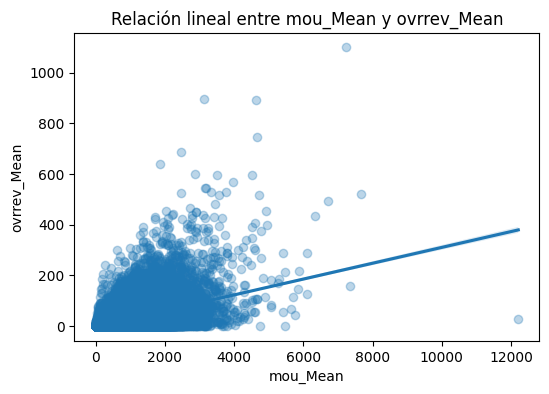

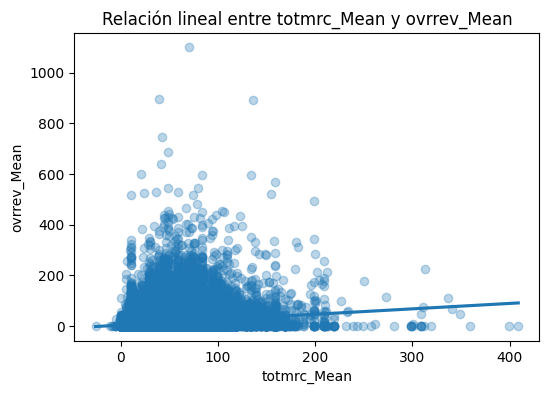

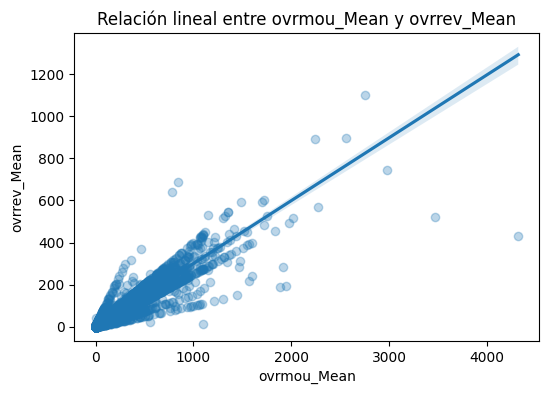

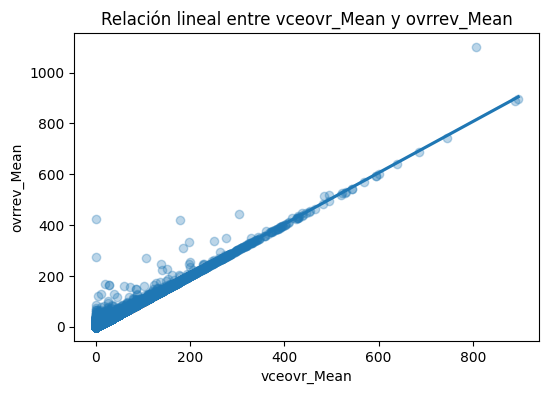

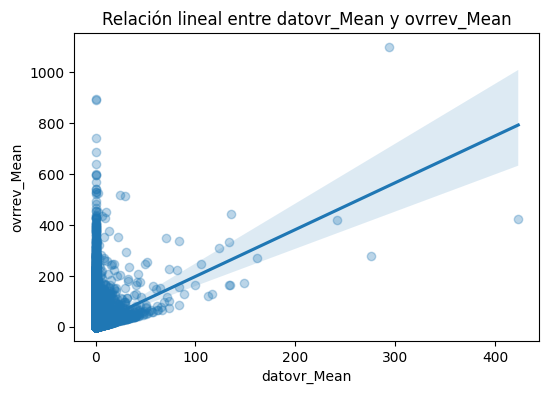

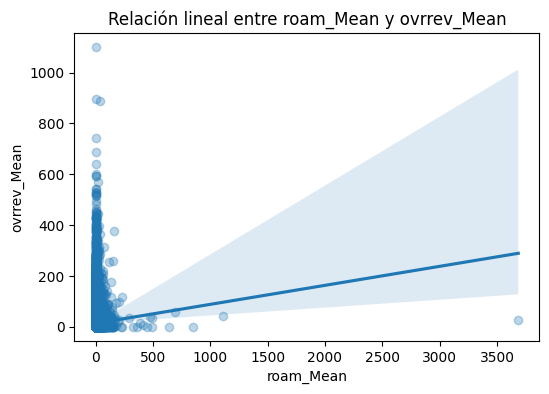

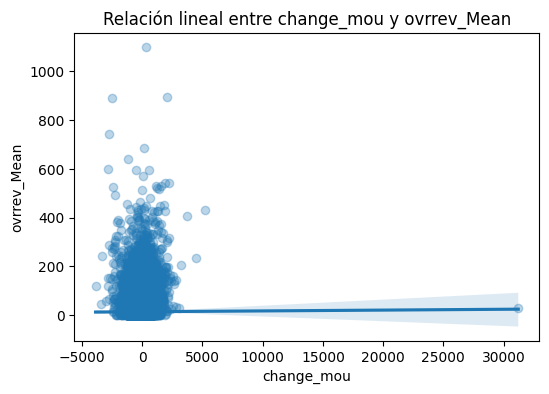

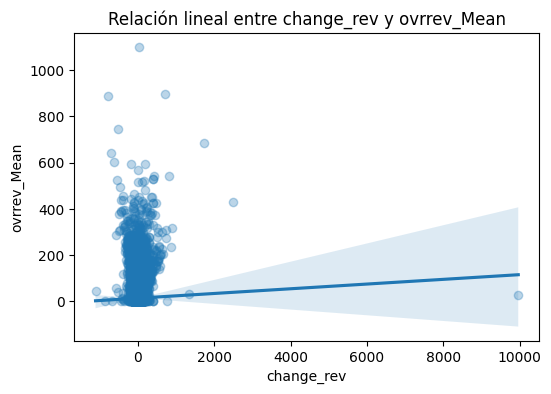

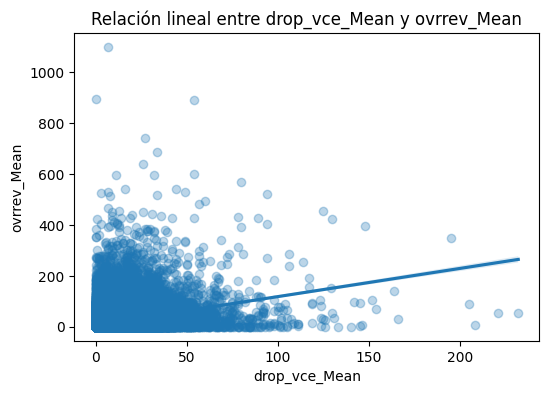

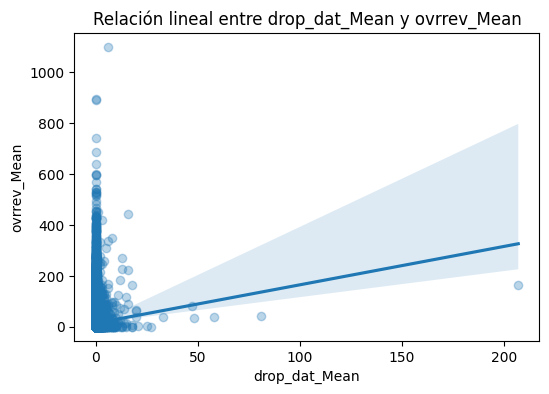

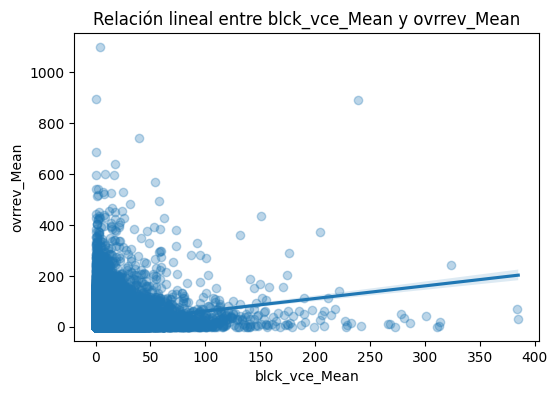

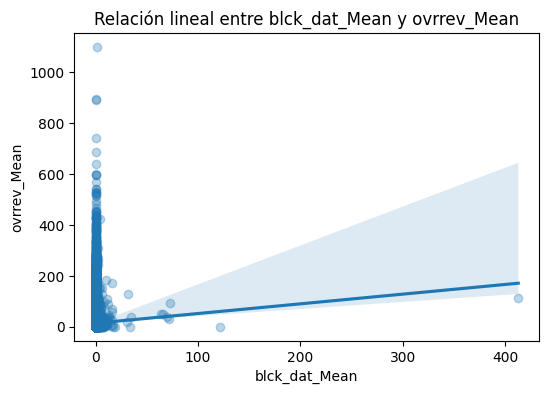

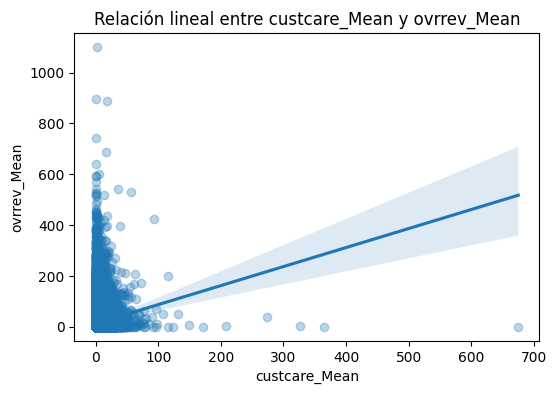

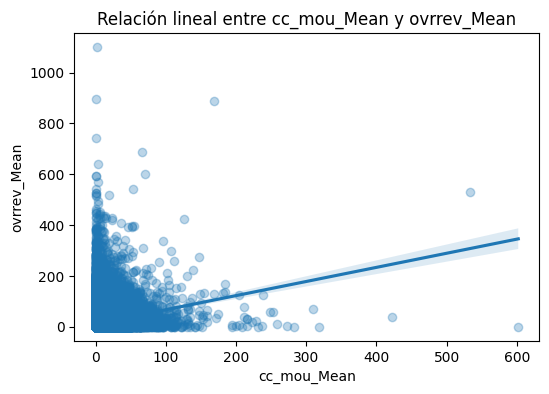

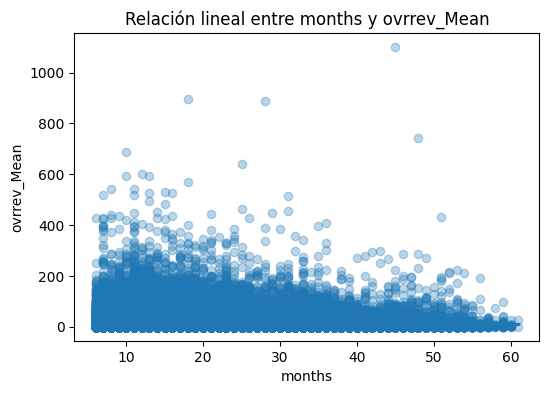

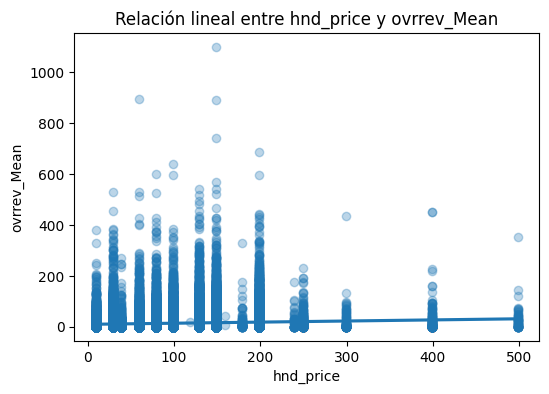

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# Variable objetivo
target = 'ovrrev_Mean'

# Lista de variables explicativas
explicativas = [
    "mou_Mean", "totmrc_Mean", "ovrmou_Mean", "vceovr_Mean",
    "datovr_Mean", "roam_Mean", "change_mou", "change_rev",
    "drop_vce_Mean", "drop_dat_Mean", "blck_vce_Mean", "blck_dat_Mean",
    "custcare_Mean", "cc_mou_Mean", "months", "hnd_price"
]

# 1. Correlación de Pearson
correlaciones = df_modelo[explicativas + [target]].corr()[target].drop(target)
print("Correlaciones con la variable objetivo:")
print(correlaciones)

# 2. Regresión lineal simple y R²
resultados = []
for col in explicativas:
    # Excluir NaN
    X = df_modelo[[col]].dropna()
    y = df_modelo.loc[X.index, target]

    # Ajustar modelo lineal
    model = LinearRegression().fit(X, y)
    r2 = r2_score(y, model.predict(X))
    resultados.append((col, r2))

# Mostrar tabla de R²
df_r2 = pd.DataFrame(resultados, columns=['Variable', 'R²']).sort_values(by='R²', ascending=False)
print("\nR² de regresión lineal simple:")
print(df_r2)

# 3. Gráficos de dispersión con línea de regresión
for col in explicativas:
    plt.figure(figsize=(6,4))
    sns.regplot(x=df_modelo[col], y=df_modelo[target], scatter_kws={'alpha':0.3})
    plt.title(f'Relación lineal entre {col} y {target}')
    plt.show()


Toda vez que conocemos que no existe una linealidad completa entre todas las variables del DATAFRAME, la mejor opcion es utiliza el modelo de XGBoost, ya que, los datos son tabulares con escalas numéricas mixtas y variables categóricas codificadas por etiquetas. XGBoost maneja todo esto sin escalado, se entrena rápidamente y proporciona importancias de características que podemos usar para explicar el modelo y tiene una API sencilla al estilo de scikit-learn

# 4. CREACION DE NUEVAS CARACTERISTICAS

In [ ]:
# Crear nueva columna: costo promedio por minuto en exceso, en caso que la division sea NAN, se asigna el valor de 0
df_modelo['costo_promedio_minuto_exceso'] = np.where(
    df_modelo['ovrmou_Mean'] > 0,
    df_modelo['ovrrev_Mean'] / df_modelo['ovrmou_Mean'], 0
)
df_modelo.head()

,ovrrev_Mean,mou_Mean,totmrc_Mean,ovrmou_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,custcare_Mean,cc_mou_Mean,months,hnd_price,Customer_ID,ovrrev_Mean_missing,mou_Mean_missing,totmrc_Mean_missing,ovrmou_Mean_missing,vceovr_Mean_missing,datovr_Mean_missing,roam_Mean_missing,change_mou_missing,change_rev_missing,hnd_price_missing,area_missing,area_ATLANTIC SOUTH AREA,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_HOUSTON AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_PHILADELPHIA AREA,area_SOUTH FLORIDA AREA,area_SOUTHWEST AREA,area_TENNESSEE AREA,costo_promedio_minuto_exceso
0,0.0,219,22.0,0,0.0,0.0,0,-157.0,-18.0,0,0,0,0,0,0,61,149.0,1000001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.000000
1,9.0,482,37.0,22,9.0,0.0,0,532.0,50.0,8,0,1,0,1,5,56,99.0,1000002,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.409091
2,0.0,10,16.0,0,0.0,0.0,0,-4.0,0.0,0,0,0,0,0,0,58,29.0,1000003,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.000000
3,0.0,7,38.0,0,0.0,0.0,0,-1.0,0.0,0,0,0,0,0,0,60,29.0,1000004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000
4,0.0,570,71.0,0,0.0,0.0,0,38.0,0.0,9,0,0,0,8,11,57,149.0,1000005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.000000


In [ ]:
df_modelo['costo_promedio_minuto_exceso'].isnull().sum()

np.int64(0)

# 5 CREACION DEL MODELO

Una vez que nuestro dataframe df_modelo esta limpio, hemos eliminado datos, imputado datos, hemos codificado los datos (one hot), en caso de la variable categorica, vamos a aplicar el modelo XGBoost, ya que el algortimo trabaja bien con datos outliders, no asume normalidad en la distibucion, es decir simetria

In [ ]:
df_clean = df_modelo.drop(columns=['Customer_ID'])

X = df_clean.drop('ovrrev_Mean', axis=1)
y = df_clean['ovrrev_Mean']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Define the model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='rmse',
    random_state=42,
)

# Train
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# 6 EVALUACION DEL MODELO

En vista de que nuestro problema de prediccion, es un problema de regresion, utilizaremos las siguientes metricas de evaluación: mse, rmse, mae, r2

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MAPE (Mean Absolute Percentage Error)
#mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("📊 Evaluación del modelo XGBoost")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

📊 Evaluación del modelo XGBoost
MSE  : 35.40
RMSE : 5.95
MAE  : 0.30
R²   : 0.9637
MAPE : 1.75%


A continuacion, realizamos un grafico de dispersion para comparar los valores reales de los predichos

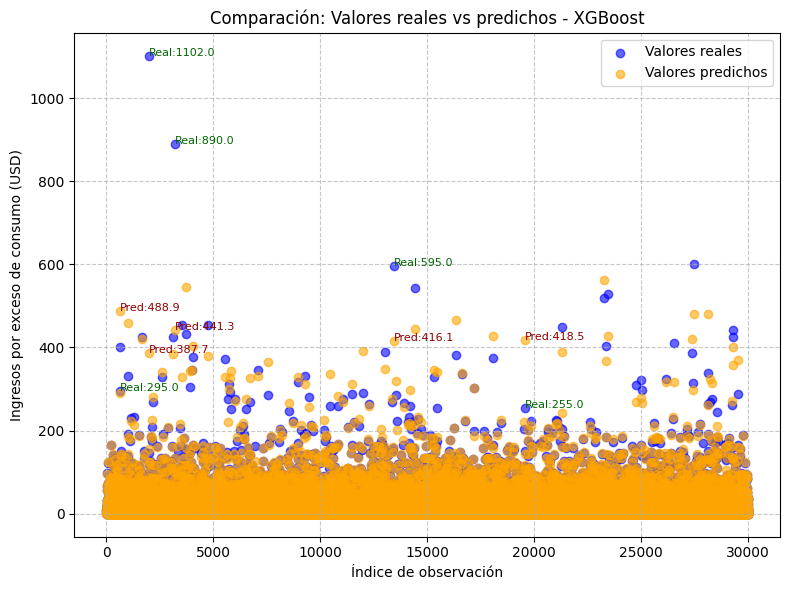

In [ ]:
plt.figure(figsize=(8,6))

# Puntos reales (valores observados)
plt.scatter(range(len(y_test)), y_test, alpha=0.6, color='blue', label='Valores reales')

# Puntos predichos (modelo XGBoost)
plt.scatter(range(len(y_pred)), y_pred, alpha=0.6, color='orange', label='Valores predichos')

# Etiquetar algunos puntos (ejemplo: los 5 con mayor error)
errores = abs(y_test - y_pred)
top_errores_original_indices = errores.nlargest(5).index

# Get the positional index for each original index that had the largest errors
for original_idx in top_errores_original_indices:
    pos_idx = y_test.index.get_loc(original_idx)

    plt.text(pos_idx, y_pred[pos_idx], f"Pred:{y_pred[pos_idx]:.1f}", fontsize=8, color='darkred')
    plt.text(pos_idx, y_test.iloc[pos_idx], f"Real:{y_test.iloc[pos_idx]:.1f}", fontsize=8, color='darkgreen')

plt.xlabel("Índice de observación")
plt.ylabel("Ingresos por exceso de consumo (USD)")
plt.title("Comparación: Valores reales vs predichos - XGBoost")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Del grafico podemos decir que el modelo predice muy bien la mayoría de los casos, especialmente en el rango medio y bajo de ingresos.

Los outliers (valores reales muy altos) son los más difíciles de ajustar, lo que es normal en modelos de regresión: suelen tener menos representatividad en el entrenamiento.

No se observan patrones sistemáticos de error, lo que confirma que el modelo generaliza correctamente.

A continuacion vamos a realizar un grafico de residuos, para conocer conocer que tan cerca esta el valor real del valor predicho

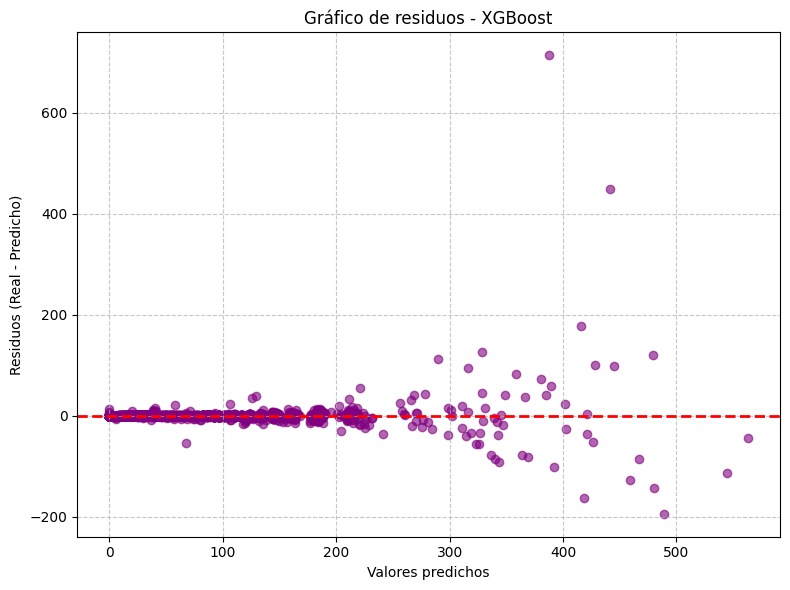

In [ ]:
# Calcular residuos
residuos = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.6, color='purple')

# Línea horizontal en cero (sin error)
plt.axhline(y=0, color='red', linestyle='--', lw=2)

plt.xlabel("Valores predichos")
plt.ylabel("Residuos (Real - Predicho)")
plt.title("Gráfico de residuos - XGBoost")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

La linea roja intercortada indica donde el modelo predice perfectamente, vemos que la mayoria de puntos morados, estan cerca de la linea roja, lo cual nos confirma la alta precision de los resultados de las metricas calculadas anteriormente, sin embargo tenemos valores que puede ser atipicos, que el modelo no esta capturando de manera precisa, probablemente por hay pocos ejemplos de esos casos en el entrenamiento

# 7 Simulación

Ahora que tengo el modelo de prediccion, en el que me entregara el valor monetario que el cliente pagara ante un posible aumento de consumo, con el objeto que le empresa actue previamente, para ofrecer un aumento de plan y lograr la fidelizacion del cliente. A continuacion vamos a plantear una simulacion asumiendo que el 60% de los clientes se acogen al aumento del plan

In [ ]:
total_predicho = np.sum(y_pred)

print(f"Valor total predicho por exceso: {total_predicho:,.2f} USD")

Valor total predicho por exceso: 399,383.06 USD


In [ ]:
print(y_pred)

[ 7.9674072e+00  1.8041650e+00 -1.1846902e-03 ...  1.7766451e-03
  3.3064579e+01  6.9738741e+00]


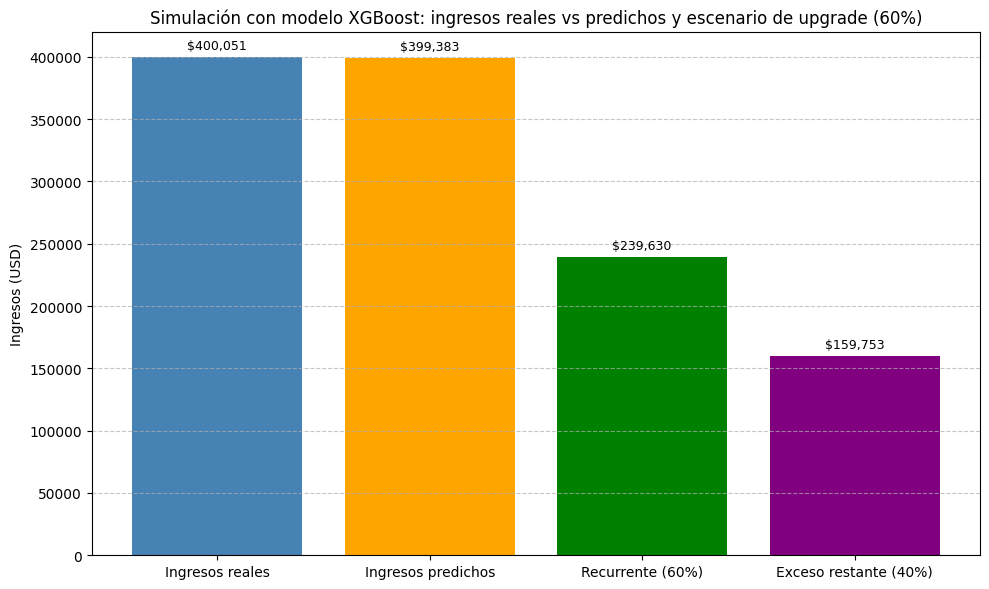

In [ ]:
ingreso_real = np.sum(y_test)
ingreso_predicho = np.sum(y_pred)

# Escenario: 60% aceptación de upgrade
tasa_upgrade = 0.6
ingreso_recurrente = ingreso_predicho * tasa_upgrade
ingreso_exceso_restante = ingreso_predicho * (1 - tasa_upgrade)

# Gráfico comparativo
labels = ['Ingresos reales', 'Ingresos predichos', 'Recurrente (60%)', 'Exceso restante (40%)']
values = [ingreso_real, ingreso_predicho, ingreso_recurrente, ingreso_exceso_restante]
colors = ['steelblue', 'orange', 'green', 'purple']

plt.figure(figsize=(10,6))
bars = plt.bar(labels, values, color=colors)

# Etiquetas con valores
for bar, valor in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ingreso_real*0.01,
             f"${valor:,.0f}", ha='center', va='bottom', fontsize=9)

plt.ylabel("Ingresos (USD)")
plt.title("Simulación con modelo XGBoost: ingresos reales vs predichos y escenario de upgrade (60%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**INTERPRETACIÓN **

🔵 Ingresos reales ($400,051)  
Representan el total observado en los datos históricos, lo que efectivamente se generó por exceso de consumo.

🟠 Ingresos predichos ($399,383)  
El modelo XGBoost reproduce casi exactamente los ingresos reales (diferencia menor al 0.2%).

🟢 Recurrente (60%) $239,630  
Simula el escenario donde el 60% de los clientes acepta el cambio de plan.
 Este monto se convertiría en ingresos estables y predecibles, reduciendo la volatilidad del flujo financiero.

🟣 Exceso restante (40%) $159,753  
Representa los clientes que mantienen su comportamiento actual (no aceptan upgrade).
Son ingresos ocasionales, pero aún contribuyen al total.

**CONCLUSION**
El modelo predice ingresos casi idénticos a los reales, lo que valida su uso para simulaciones comerciales.

Si el 60% de los clientes migra a planes superiores, la empresa asegura $239,630 mensuales recurrentes, lo que estabiliza el flujo de caja y mejora la satisfacción del cliente.

El total combinado (recurrente + exceso restante) mantiene el mismo nivel de ingresos, pero con una estructura más saludable: 60% estable / 40% variable.

El modelo no solo predice con precisión, sino que permite transformar ingresos ocasionales en recurrentes, fortaleciendo la sostenibilidad comercial.